# Downloading and managing data

In this tutorial you are going to learn how to:

<div class="alert alert-block alert-warning">
    
**[Writing a NOMAD query](#Writing-a-NOMAD-query)**

**[Querying the NOMAD API](#Querying-the-NOMAD-API)**

**[Analyzing the data](#Analyzing-the-data)**

**[Automatic processing](#Automatic-processing)**
   
</div>

Let's get started!

- creating a materials database
- choosing a backend and api
- refer to NOMAD download tutorial for actual engineering of downloads
- updating the database with custom properties
- creating and analysing dataframes

In [1]:
query = {
    "results.material.structural_type:any": [
      "bulk"
    ],
    "results.method.method_name:any": [
      "DFT"
    ],
    "datasets.dataset_name:any": [
      "Hybrid organic inorganic perovskite"
    ],
    "results.properties.available_properties:all": [
      "dos_electronic"
    ],
    "results.material.elements:all": [
      "O"
    ]
  }

## Using an API to download data

In [33]:
api = API()

In [29]:
materials = api.get_calculations_by_search(query, max_entries=1)

Found 10 entries
Possibly not all entries discovered due to max_entries limit
Finished download.


In [30]:
example_material = materials[0]

In [56]:
example_material

Material(mid = -GZSgfF01_QczeG08-_2H0D9NxxB, data = {'archive'}, properties = set())

In [10]:
from madas.plotting import plot_material

In [12]:
example_material.atoms

Atoms(symbols='I3H4PbNO', pbc=True, cell=[[5.98843701, 0.737824, 0.85327691], [0.75345293, 6.59365117, -0.33087221000000006], [1.15697688, -0.77351248, 6.32327361]])

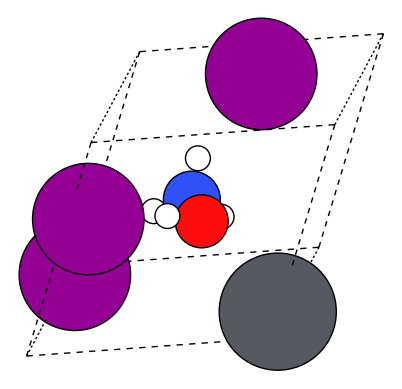

In [18]:
plot_material(example_material,
              repeat=[1,1,1], 
              show_unit_cell=2)

In [39]:
print(example_material.data.keys())

dict_keys(['archive'])


In [40]:
print(example_material.data['archive'].keys())

dict_keys(['processing_logs', 'run', 'workflow', 'metadata', 'results', 'm_ref_archives'])


In [41]:
print(example_material.properties)

{}


In [ ]:
example_material.get_data_by_path()

## Storing `Material`s in a `MaterialsDatabase`

In [42]:
from madas import MaterialsDatabase

In [43]:
db = MaterialsDatabase(filename='hybrid_organic_inorganic_perovskites.db')

In [44]:
len(db)

0

In [98]:
db.fill_database(query)

2026-03-30 19:24:58,673 - hybrid_organic_inorganic_perovskites_log - INFO - Query has already been performed.


In [47]:
len(db)

400

In [50]:
with open('data/.hybrid_organic_inorganic_perovskites_logs/hybrid_organic_inorganic_perovskites_errors.log', 'r') as f_:
    logfile=f_.readlines()

In [54]:
print(''.join(logfile[-5:]))

2026-03-30 18:40:44,841 - hybrid_organic_inorganic_perovskites_api - INFO - Wrote material with id r1q7K-nO6x88kxrErue3N1yTk_uF.
2026-03-30 18:40:44,851 - hybrid_organic_inorganic_perovskites_api - INFO - Wrote material with id RymKmDOkPptHv_aKAnT0qlXzySWr.
2026-03-30 18:40:44,868 - hybrid_organic_inorganic_perovskites_api - INFO - Wrote material with id kH9VJ5-dk901FFZJ_PmrcojodfKN.
2026-03-30 18:40:44,877 - hybrid_organic_inorganic_perovskites_api - INFO - Wrote material with id Omah2_6_F-iSByQCJmUGoqo6gkf2.
2026-03-30 18:40:44,890 - hybrid_organic_inorganic_perovskites_api - INFO - Wrote material with id m5ik-USpD2-bzxHkT1rInpyRZH4r.



Benefits of a logfile: 
- track provenance
- auto timing

In [55]:
db[0]

Material(mid = r0nrMz72q7RGOSq9TzFu8ydzOiS7, data = {'archive'}, properties = set())

In [57]:
db['-GZSgfF01_QczeG08-_2H0D9NxxB']

Material(mid = -GZSgfF01_QczeG08-_2H0D9NxxB, data = {'archive'}, properties = set())

In [59]:
from madas.utils import tqdm

In [60]:
volumes = []
for entry in tqdm(db):
    volumes.append(entry.atoms.get_volume())

  0%|          | 0/400 [00:00<?, ?it/s]

In [61]:
import matplotlib.pyplot as plt

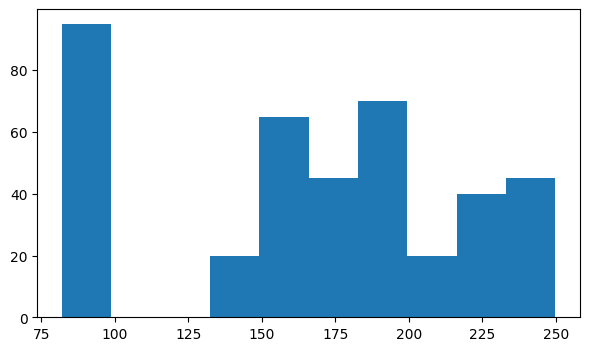

In [63]:
plt.figure(figsize=(7,4))
plt.hist(volumes)
plt.show()

## Derive properties in your database

In [67]:
from madas.utils import print_key_paths, resolve_nested_dict

In [142]:
print_key_paths('band_gap', example_material.data)

/archive/run/0/calculation/0/dos_electronic/0/band_gap
/archive/results/properties/electronic/dos_electronic/band_gap


In [69]:
resolve_nested_dict(example_material.data, 'archive/results/properties/electronic/dos_electronic/band_gap')

[{'index': 0,
  'energy_highest_occupied': 1.9548157111433998e-19,
  'energy_lowest_unoccupied': 1.9548157111433998e-19}]

In [74]:
from scipy.constants import electron_volt

In [90]:
gap_data = resolve_nested_dict(example_material.data, 'archive/results/properties/electronic/dos_electronic/band_gap')[0]

In [91]:
gap = (gap_data['energy_lowest_unoccupied'] - gap_data['energy_highest_occupied']) / electron_volt

In [92]:
gap

0.0

In [93]:
from madas import Material

In [94]:
def get_gap(material: Material) -> float:
    gap_data = resolve_nested_dict(material.data, 'archive/results/properties/electronic/dos_electronic/band_gap')[0]
    gap = (gap_data['energy_lowest_unoccupied'] - gap_data['energy_highest_occupied']) / electron_volt
    return gap

In [95]:
band_gaps = []
for entry in tqdm(db):
    band_gaps.append(get_gap(entry))

  0%|          | 0/400 [00:00<?, ?it/s]

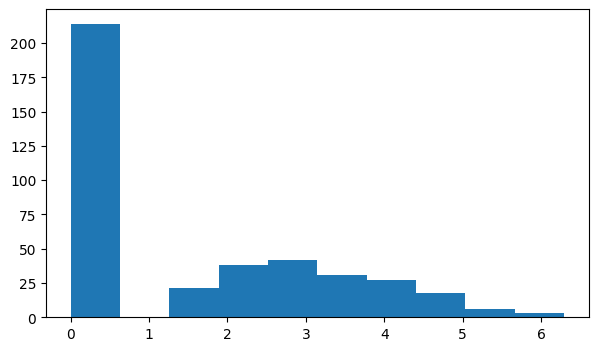

In [96]:
plt.figure(figsize=(7,4))
plt.hist(band_gaps)
plt.show()

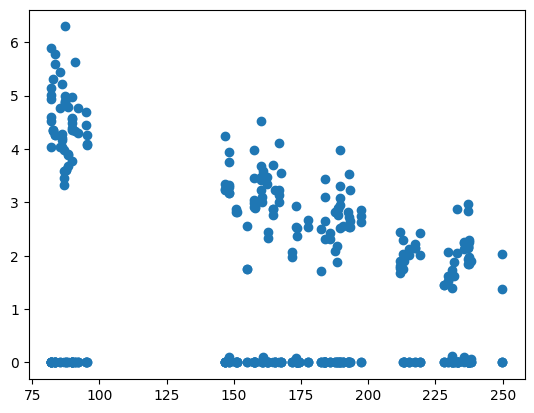

In [97]:
plt.scatter(volumes, band_gaps)

In [108]:
mids, properties_dicts = [], []
for entry in tqdm(db):
    mids.append(entry.mid)
    properties_dicts.append({'band_gap':get_gap(entry), 'volume':entry.atoms.get_volume()})

  0%|          | 0/400 [00:00<?, ?it/s]

In [103]:
db.update_entries(mids, properties_dicts)

In [105]:
db[0]

Material(mid = r0nrMz72q7RGOSq9TzFu8ydzOiS7, data = {'archive'}, properties = {'band_gap', 'volume'})

## Retrieving properties

In [107]:
band_gaps = db.get_properties('band_gap')

  0%|          | 0/400 [00:00<?, ?it/s]

In [109]:
db.get_property_dataframe(['volume', 'band_gap'])

,volume,band_gap
r0nrMz72q7RGOSq9TzFu8ydzOiS7,157.928368,0.0000
YumVG0mgYxxxOTC72wIUzs61rJ9v,166.829320,3.0095
jzLbwRjTlqWn5pXQDe_LUg9sE9ev,83.557337,0.0000
JOZV8Qrisci7je7p1JDNvcgnzghQ,166.829320,3.2333
qCShm0aPVJibooRk35j4gTWGg5u4,89.953196,4.9635
...,...,...
r1q7K-nO6x88kxrErue3N1yTk_uF,197.304774,2.8635
RymKmDOkPptHv_aKAnT0qlXzySWr,233.485490,0.0000
kH9VJ5-dk901FFZJ_PmrcojodfKN,95.482142,4.0746
Omah2_6_F-iSByQCJmUGoqo6gkf2,233.485490,0.0000


In [121]:
dataframe = db.get_property_dataframe(['volume', 'band_gap', 'archive/results/material/symmetry/space_group_number'])

In [122]:
dataframe.describe()

,volume,band_gap,archive/results/material/symmetry/space_group_number
count,400.000000,400.000000,400.0
mean,166.781115,1.475016,1.0
std,51.909401,1.747633,0.0
min,82.050231,0.000000,1.0
25%,146.843302,0.000000,1.0
50%,173.365157,0.000000,1.0
75%,212.009954,2.880850,1.0
max,249.762117,6.293500,1.0
